In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
import itertools
import scipy 
import math
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)

from utils import PiecewiseGQ2D_weights_points, SquareMesh2D_points, split_domain_boundary
from utils import s2_uniform_grid_init
from utils import output_convergence_order_l2
from utils import plot_err_convergence

In [2]:
class ShallowReLUkNetwork:
    def __init__(self, ws, bs, train_pts, k=1, m1=1, m2=1):
        self.n = ws.shape[0]
        self.W = ws 
        self.b = bs
        self.k = k
        self.m1 = m1 
        self.m2 = m2
        pts_dom, pts_bd = split_domain_boundary(train_pts)
        self.pts_dom = pts_dom #.requires_grad_(True)
        self.pts_bd = pts_bd
    
    def feat_extract(self, x):
        return F.relu(x @ self.W.t() + self.b) ** self.k

    def target(self, x):
        z = torch.sin(self.m1 * pi*x[:,0:1])*torch.sin(self.m2 * pi*x[:,1:2])
        return z 
    
    def rhs(self, x):
        u = torch.sin(self.m1 * pi * x[:, 0:1]) * torch.sin(self.m2 * pi * x[:, 1:2])
        coeff = 1 + (self.m1 * pi) ** 2 + (self.m2 * pi) ** 2
        return coeff * u

    def lapfeat(self, x):
        """
        Analytic Laplacian of ReLU^k features
        x: (N, d)
        Returns: (N, m)
        """
        # pre-activation
        z = x @ self.W.t() + self.b    # (N, m)

        # mask for ReLU active region
        active = (z > 0).float()

        if self.k < 2:
            # Laplacian is identically zero if k=0 or 1
            return torch.zeros_like(z)

        # squared row norms of W: (m,)
        W_norm2 = (self.W**2).sum(dim=1)   # (m,)
        # expand to (N, m)
        W_norm2 = W_norm2.unsqueeze(0).expand_as(z)

        lap = self.k * (self.k - 1) * (z ** (self.k - 2)) * W_norm2 * active
        return lap

    def assemble(self):
        gs = self.feat_extract(self.pts_dom)
        lap_gs = self.lapfeat(self.pts_dom)
        A_dom = -lap_gs + gs
        b_dom = self.rhs(self.pts_dom)
        A_bd = self.feat_extract(self.pts_bd)
        b_bd = self.target(self.pts_bd)
        A = torch.concat([A_dom, A_bd])
        b = torch.concat([b_dom, b_bd])       
        return A, b

    def solve(self):
        A, b = self.assemble()

        c = 100.0 
        for i in range(len(A)):
            max_a = abs(A[i,:]).max()
            max_b = A[i,:].max()
            if max_a != max_b: 
                ratio = -c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
            else: 
                ratio = c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
        alpha = scipy.linalg.lstsq(A.numpy(),b.numpy())[0]
        self.alpha = torch.tensor(alpha)
        
    def forward(self, x):
        return self.feat_extract(x) @ self.alpha
    
    def eval(self, x):
        y_ref = self.target(x)
        y_pred = self.forward(x)
        rel_errl2 = (y_pred - y_ref).norm() / y_ref.norm()
        return rel_errl2.item()
    def eval_h1(self, x): 
        if x.requires_grad != True:
            x.requires_grad_(True)
        target_values = self.target(x)
        target_grad = torch.autograd.grad(outputs=target_values, inputs=x, grad_outputs= torch.ones_like(target_values),retain_graph=True, create_graph=True)[0] 
        target_x = target_grad[:,0:1]
        target_y = target_grad[:,1:2] 

        model_values = self.forward(x)
        model_grad = torch.autograd.grad(outputs=model_values, inputs=x, grad_outputs=torch.ones_like(model_values),retain_graph=True, create_graph=True)[0]
        model_x = model_grad[:,0:1]
        model_y = model_grad[:,1:2]
    
        model_grad = torch.autograd.grad(outputs=model_values, inputs=x, grad_outputs=torch.ones_like(model_values))[0] # no need to create or retain_graph, save memory 
        model_x = model_grad[:,0:1]
        model_y = model_grad[:,1:2] 
        return torch.sum((model_x - target_x)**2 +  (model_y - target_y)**2/x.size(0))**0.5 


num neuron : 11 - rel l2 : 2.0076e+01 - h1 : 5.6927e+03
num neuron : 23 - rel l2 : 5.8451e+01 - h1 : 1.9875e+04
num neuron : 43 - rel l2 : 1.1105e+01 - h1 : 5.0653e+03
num neuron : 69 - rel l2 : 1.1377e+01 - h1 : 5.3038e+03
num neuron : 125 - rel l2 : 1.7911e+01 - h1 : 1.1513e+04
num neuron : 239 - rel l2 : 1.2099e+00 - h1 : 7.1207e+02
num neuron : 457 - rel l2 : 4.1055e-01 - h1 : 4.0755e+02
num neuron : 909 - rel l2 : 1.4600e-01 - h1 : 1.7235e+02
num neuron : 1809 - rel l2 : 5.3600e-02 - h1 : 7.3125e+01


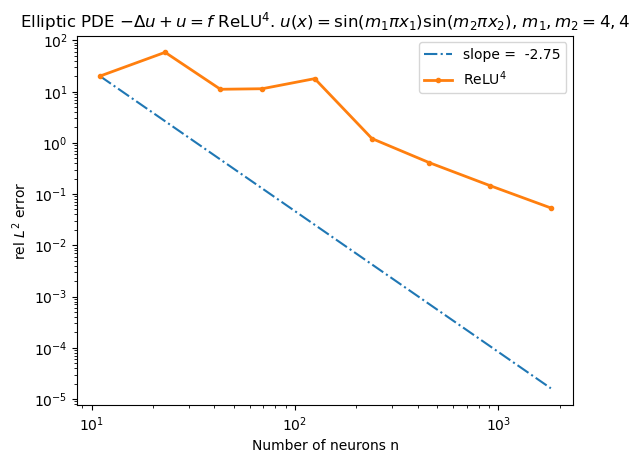

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
11 		 & 2.008e+01 &		 *  \\ \hline  

23 		 &  5.845e+01 &  		 -1.45  \\ \hline  

43 		 &  1.111e+01 &  		 2.65  \\ \hline  

69 		 &  1.138e+01 &  		 -0.05  \\ \hline  

125 		 &  1.791e+01 &  		 -0.76  \\ \hline  

239 		 &  1.210e+00 &  		 4.16  \\ \hline  

457 		 &  4.106e-01 &  		 1.67  \\ \hline  

909 		 &  1.460e-01 &  		 1.50  \\ \hline  

1809 		 &  5.360e-02 &  		 1.46  \\ \hline  

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
11 		 & 5.693e+03 &		 *  \\ \hline  

23 		 &  1.987e+04 &  		 -1.70  \\ \hline  

43 		 &  5.065e+03 &  		 2.18  \\ \hline  

69 		 &  5.304e+03 &  		 -0.10  \\ \hline  

125 		 &  1.151e+04 &  		 -1.30  \\ \hline  

239 		 &  7.121e+02 &  		 4.29  \\ \hline  

457 		 &  4.076e+02 &  		 0.86  \\ \hline  

909 		 &  1.724e+02 &  		 1.25  \\ \hline  

1809 		 &  7.313e+01 &  		 1.25  \\ \hline  



In [6]:
%matplotlib inline 

x_train = SquareMesh2D_points(0,1,200)
x_test = SquareMesh2D_points(0,1,150)

k = 4
m1 = 4
m2 = 4
neuron_num_arr= np.array([2**i for i in range(4,13)]) 
neuron_arr = []
rel_errl2_arr = []
h1_err_arr = []
for i, n in enumerate(neuron_num_arr):
    ws, bs = s2_uniform_grid_init(n, k=k)
    model = ShallowReLUkNetwork(
        ws, bs, x_train, k=k, m1=m1, m2=m2)
    model.solve()
    rel_errl2 = model.eval(x_test)
    neuron_arr.append(model.n)
    rel_errl2_arr.append(rel_errl2)
    
    h1_err = model.eval_h1(x_test).detach().item() 
    h1_err_arr.append(h1_err)
    print('num neuron : {:} - rel l2 : {:.4e} - h1 : {:.4e}'.format(model.n, rel_errl2, h1_err))
title = "Elliptic PDE $-\Delta u + u = f$ ReLU$^{}$. $u(x) = \sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, m1, m2)
plot_err_convergence(k,2,torch.tensor(neuron_arr), rel_errl2_arr,title)
output_convergence_order_l2(torch.tensor(neuron_arr), rel_errl2_arr)
output_convergence_order_l2(torch.tensor(neuron_arr), h1_err_arr)

In [14]:
h1_err

tensor([[ 33.7989],
        [ 32.1423],
        [ 30.5032],
        ...,
        [134.7024],
        [137.3100],
        [139.9312]], grad_fn=<PowBackward0>)

In [24]:
from model import ShallowReLUkSolver
from model import PouShallowReLUkSolver 

In [ ]:
%matplotlib inline 
import os 
from utils import SquareMesh2D_points
from utils import s2_uniform_grid_init
from utils import plot_err_convergence_levels
from model import ShallowReLUkSolver
from model import PouShallowReLUkSolver2 


def run_exp(k, m, l, nmin=6, nmax=13, neuron_max=2500):
    x_train = SquareMesh2D_points(0,1,200)
    x_test = SquareMesh2D_points(0,1,150)

    if l == 0:
        # Global fitter
        neuron_num_arr= np.array([2**i for i in range(nmin, nmax)]) 
        neuron_arr = []
        rel_errl2_arr = []
        for i, n in enumerate(neuron_num_arr):
            ws, bs = s2_uniform_grid_init(n, k=k)
            fitter = ShallowReLUkSolver(
                ws, bs, x_train, k=k, m1=m, m2=m)
            if fitter.n > neuron_max:
                break
            fitter.solve()
            rel_errl2 = fitter.eval(x_test)
            neuron_arr.append(fitter.n)
            rel_errl2_arr.append(rel_errl2)
            h1_err = fitter.eval_h1(x_test).detach().item()
            print('num neuron : {:} - rel l2 : {:.4e} - rel h1 : {:.4e}'.format(fitter.n, rel_errl2, h1_err))
    else:
        neuron_num_arr= np.array([2**i for i in range(2,11)]) 
        neuron_arr = []
        rel_errl2_arr = []
        for i, n in enumerate(neuron_num_arr):
            ws, bs = s2_uniform_grid_init(n, k=k)
            fitter = PouShallowReLUkSolver2(
                ws, bs, x_train, l=l, k=k, m1=m, m2=m)
            if fitter.J * fitter.n > neuron_max:
                break 
            fitter.solve()
            rel_errl2 = fitter.eval(x_test)
            neuron_arr.append(fitter.n*fitter.J)
            rel_errl2_arr.append(rel_errl2)
            h1_err = fitter.eval_h1(x_test).detach().item() 
            print('local {:} num neuron : {:} - rel l2 : {:.4e} - rel h1 : {:.4e}'.format(fitter.J, fitter.n*fitter.J, rel_errl2, h1_err))

    return np.array(neuron_arr), np.array(rel_errl2_arr)

if __name__ == '__main__':

    k_list = [4]
    m_list = [4]
    l_list = [2,3,4]
    neurons_dict = {}
    errs_dict = {}
    for k in k_list:
        for m in m_list:
            print(f'start exp (elliptic) : k {k} - m {m}')
            # neuron_dict_outpath = f'./logs/elliptic_neurons_k{k}_m{m}.npy'
            # err_dict_outpath = f'./logs/elliptic_errs_k{k}_m{m}.npy'

            # if os.path.exists(neuron_dict_outpath) & os.path.exists(err_dict_outpath):
            #     neurons_dict = np.load(neuron_dict_outpath, allow_pickle=True).item()
            #     errs_dict = np.load(err_dict_outpath, allow_pickle=True).item()
            # else:
            for l in l_list:
                neurons, errs = run_exp(k, m, l, 2, 13)
                neurons_dict[l] = neurons
                errs_dict[l] = errs
                
                # np.save(f'./logs/elliptic_neurons_k{k}_m{m}.npy', neurons_dict)
                # np.save(f'./logs/elliptic_errs_k{k}_m{m}.npy', errs_dict)
                
            title = "$-\Delta u + u = f$. ReLU$^{}$. $u(x_1, x_2) = \sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, m, m)
            outpath = f'./figures/pou2_elliptic_k{k}_m{m}.jpg'
            print(f"save figure {outpath}")
            plot_err_convergence_levels(relu_k=k, d=2,
                            neuron_dict=neurons_dict,
                            err_dict=errs_dict,
                            levels=l_list,
                            title=title,
                            outpath=outpath)



start exp (elliptic) : k 4 - m 4
local 9 num neuron : 27 - rel l2 : 2.6543e+00 - rel h1 : 2.6800e+03
local 9 num neuron : 54 - rel l2 : 3.7393e+00 - rel h1 : 2.7328e+03
local 9 num neuron : 99 - rel l2 : 8.8983e+00 - rel h1 : 4.2442e+03
local 9 num neuron : 207 - rel l2 : 3.7711e+00 - rel h1 : 1.8627e+03
local 9 num neuron : 387 - rel l2 : 6.0009e-01 - rel h1 : 4.4818e+02
local 9 num neuron : 621 - rel l2 : 3.8954e-01 - rel h1 : 4.2429e+02
local 9 num neuron : 1125 - rel l2 : 1.9906e-01 - rel h1 : 1.3157e+02
local 9 num neuron : 2151 - rel l2 : 1.7070e-02 - rel h1 : 5.9742e+01
local 25 num neuron : 75 - rel l2 : 1.1797e+00 - rel h1 : 1.1178e+03
local 25 num neuron : 150 - rel l2 : 1.3476e+00 - rel h1 : 1.3171e+03
local 25 num neuron : 275 - rel l2 : 1.2214e+00 - rel h1 : 1.2500e+03
local 25 num neuron : 575 - rel l2 : 2.8986e-02 - rel h1 : 5.0599e+01
local 25 num neuron : 1075 - rel l2 : 1.3611e-02 - rel h1 : 1.7541e+01
local 25 num neuron : 1725 - rel l2 : 6.6238e-03 - rel h1 : 1.0360

KeyError: 4

In [8]:
l = 2 
rng = 1 / 2**(l)
cntr_1d = torch.linspace(0, 1, 2**(l-1)+1).reshape(-1, 1)
print(cntr_1d)

tensor([[0.0000],
        [0.5000],
        [1.0000]])


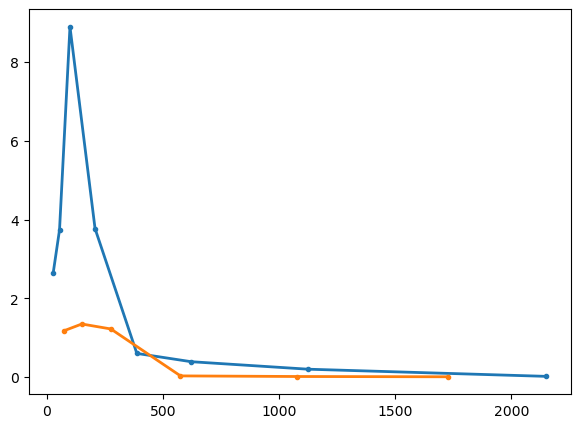

In [9]:
plt.show()